## K-Means Clustering Algorithm from Scratch in Python

K-Means is one of the most popular **unsupervised** machine learning algorithms. It partitions a dataset into **K** distinct, non-overlapping clusters based on feature similarity. "Unsupervised" means we do not provide the algorithm with labeled data -- it discovers structure on its own.

**How the algorithm works:**

1. **Initialization**: Randomly select K data points from the dataset as initial cluster centroids.
2. **Assignment**: Assign each data point to the nearest centroid based on a distance metric (Euclidean distance).
3. **Update**: Recalculate each centroid as the mean of all data points currently assigned to that cluster.
4. **Repeat**: Steps 2 and 3 are repeated until the centroids no longer change (convergence) or a maximum number of iterations is reached.

In this notebook, we implement K-Means entirely from scratch using only NumPy, and then test it on a synthetic dataset.

### Step 1: Import Libraries

We need three libraries:

- **NumPy**: For all numerical operations -- vector arithmetic, random sampling, computing means, etc.
- **Matplotlib**: For plotting the clusters at each iteration so we can visualize how the algorithm progresses.
- **Seaborn**: Provides enhanced plot styling on top of Matplotlib.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Step 2: Define the Distance Metric

K-Means needs a way to measure how "close" a data point is to a centroid. We use **Euclidean distance**, the straight-line distance between two points in n-dimensional space.

For two points $x_1 = (a_1, a_2, \ldots, a_n)$ and $x_2 = (b_1, b_2, \ldots, b_n)$, the Euclidean distance is:

$$
d(x_1, x_2) = \sqrt{\sum_{i=1}^{n} (a_i - b_i)^2}
$$

This is the generalization of the Pythagorean theorem to n dimensions. For example, in 2D it reduces to the familiar formula $\sqrt{(a_1 - b_1)^2 + (a_2 - b_2)^2}$.

In [2]:
def euclidean_distance(x1, x2):
    return np.sqrt(np.sum((x1 - x2) ** 2))

### Step 3: Implement the K-Means Class

The `KMeans` class encapsulates the entire algorithm. Here is what each method does:

| Method | Purpose |
|---|---|
| `__init__` | Sets up hyperparameters (K, max iterations) and initializes empty cluster lists and centroids. |
| `predict(X)` | The main entry point. Picks random initial centroids, then alternates between assigning points to clusters and recomputing centroids until convergence. |
| `_create_clusters` | Assigns every data point to the cluster whose centroid is nearest. Returns K lists of point indices. |
| `_closest_centroid` | Computes the Euclidean distance from one point to every centroid and returns the index of the closest one. |
| `_get_centroids` | Computes new centroids by averaging all points in each cluster. |
| `_is_converged` | Checks whether centroids have stopped moving (total displacement is zero). |
| `_get_cluster_labels` | Converts cluster assignments into a flat label array (one label per data point). |
| `plot` | Visualizes the current clusters and centroids as a scatter plot. |

In [3]:
class KMeans:

    def __init__(self, K=5, max_iters=100, plot_steps=False):
        self.K = K
        self.max_iters = max_iters
        self.plot_steps = plot_steps
        self.iteration = 0

        # list of sample indices for each cluster
        self.clusters = [[] for _ in range(self.K)]

        # the centres (cluster centroid) for each cluster
        self.centroids = []

    def predict(self, X):
        self.X = X
        self.n_samples, self.n_features = X.shape

        # initialize
        random_sample_idxs = np.random.choice(self.n_samples, self.K, replace=False)

        # Here we are choosing three random points from the dataset as initial points
        self.centroids = [self.X[idx] for idx in random_sample_idxs]

        # optimize clusters
        for _ in range(self.max_iters):
            # assign samples to closest centroids (create clusters)
            self.clusters = self._create_clusters(self.centroids)
            self.iteration += 1

            if self.plot_steps:
                self.plot()

            # calculate new centroids from the clusters
            centroids_old = self.centroids
            self.centroids = self._get_centroids(self.clusters)

            if self._is_converged(centroids_old, self.centroids):
                break

        # classify samples as the index of their clusters
        return self._get_cluster_labels(self.clusters)


    def _get_cluster_labels(self, clusters):
        # each sample will get the label of the cluster it was assigned to
        labels = np.empty(self.n_samples)
        for cluster_idx, cluster in enumerate(clusters):
            for sample_idx in cluster:
                labels[sample_idx] = cluster_idx

        return labels
    

    def _create_clusters(self, centroids):
        # assign the samples to the closest centroids
        clusters = [[] for _ in range(self.K)]
        for idx, sample in enumerate(self.X):
            centroid_idx = self._closest_centroid(sample, centroids)
            clusters[centroid_idx].append(idx)
        return clusters
    

    def _closest_centroid(self, sample, centroids):
        # distance of the current sample to each centroid
        distances = [euclidean_distance(sample, point) for point in centroids]
        closest_idx = np.argmin(distances)
        return closest_idx


    def _get_centroids(self, clusters):
        # assign mean value of clusters to centroids
        centroids = np.zeros((self.K, self.n_features))
        for cluster_idx, cluster in enumerate(clusters):
            cluster_mean = np.mean(self.X[cluster], axis=0)
            centroids[cluster_idx] = cluster_mean
        return centroids
    

    def _is_converged(self, centroids_old, centroids):
        # distances between old and new centroids, for all centroids
        distances = [euclidean_distance(centroids_old[i], centroids[i]) for i in range(self.K)]
        return sum(distances) == 0
    

    def plot(self, title=None):
        fig, ax = plt.subplots(figsize=(8, 6))

        for i, index in enumerate(self.clusters):
            point = self.X[index].T
            ax.scatter(*point)

        for point in self.centroids:
            ax.scatter(*point, marker="x", color="black", linewidth=2)

        ax = plt.gca()
        ax.set_aspect('equal', adjustable='box')
        if title:
            plt.title(title)
        else:
            plt.title(f"Iteration: {self.iteration}")
        plt.grid()
        plt.show()

### Step 4: Test the Implementation

We now test our K-Means implementation on a synthetic dataset. The plan is:

1. Generate a dataset with a known cluster structure using `make_blobs`.
2. Standardize the features so that no single feature dominates the distance calculation.
3. Run K-Means with `plot_steps=True` and visualize each iteration to watch the algorithm converge.

#### 4.1 Generate Synthetic Data

We use `sklearn.datasets.make_blobs` to create a 2D dataset with 500 samples and 3 cluster centers. This gives us data with a known ground truth, which makes it easy to visually verify whether our algorithm is working correctly.

- `centers=3`: Three distinct groups of points.
- `n_features=2`: Two features, so we can plot the data on a 2D scatter plot.
- `random_state=40`: Ensures reproducibility -- the same data is generated every time we run this cell.

In [4]:
from sklearn.datasets import make_blobs
from sklearn.preprocessing import StandardScaler

X, y = make_blobs(centers=3, n_samples=500, n_features=2, shuffle=True, random_state=40)

print("Dataset shape:", X.shape)

Dataset shape: (500, 2)


#### 4.2 Feature Scaling

Before running K-Means, we standardize the features using `StandardScaler`. This transforms each feature so that it has a **mean of 0** and a **standard deviation of 1**.

**Why is this necessary?** K-Means uses Euclidean distance, which is sensitive to feature scale. If one feature ranges from 0 to 1000 and another from 0 to 1, the first feature would dominate the distance calculation and the second would have almost no influence. Standardization ensures all features contribute equally to the distance metric.

In [5]:
X_std = StandardScaler().fit_transform(X)

#### 4.3 Run K-Means

We instantiate our `KMeans` class with:

- `K=3`: We expect 3 clusters (matching the 3 blob centers we generated).
- `max_iters=10`: Allow up to 10 iterations for convergence.
- `plot_steps=True`: Plot the cluster assignments after each iteration so we can watch the algorithm converge step by step.

The `predict` method returns a label array where each element indicates which cluster the corresponding data point belongs to. In the plots below, each color represents a different cluster, and the black **x** markers show the current centroid positions. Notice how the centroids move toward the center of their respective clusters with each iteration until they stabilize.

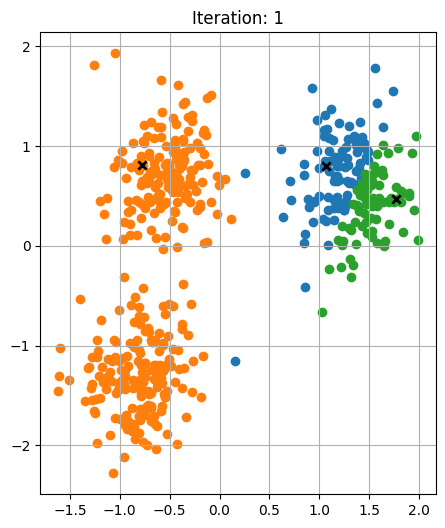

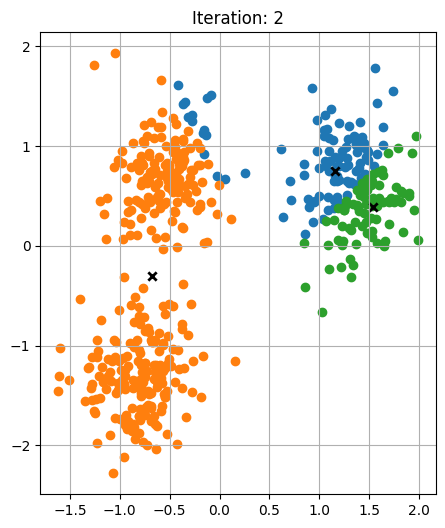

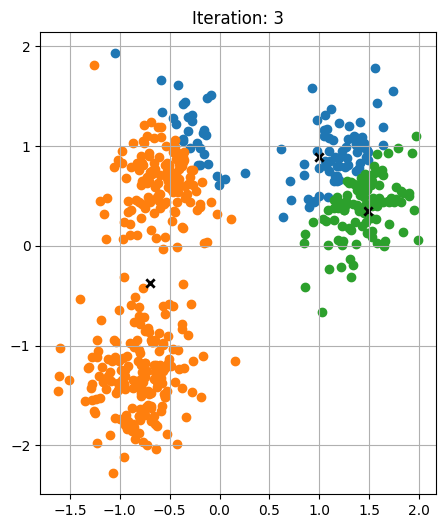

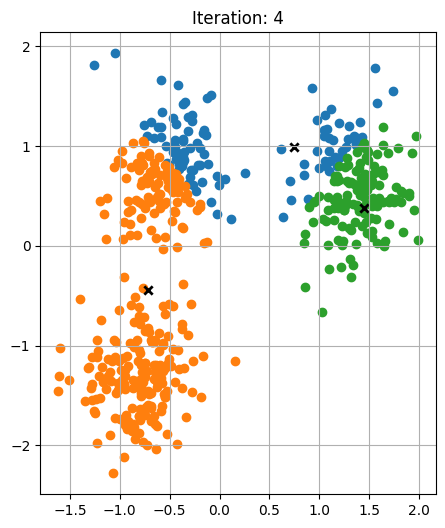

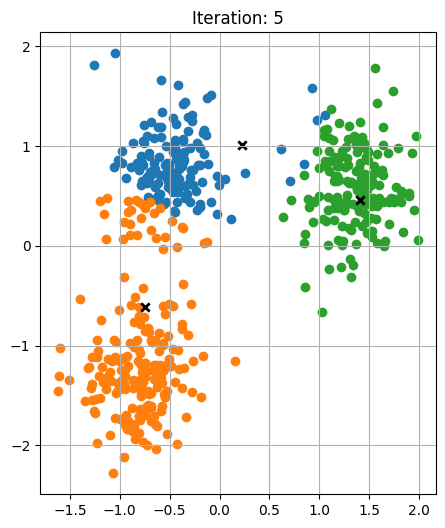

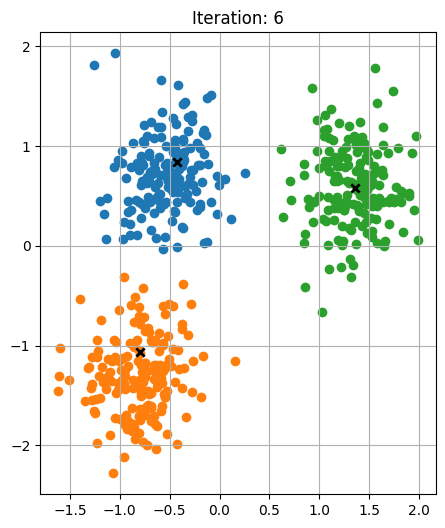

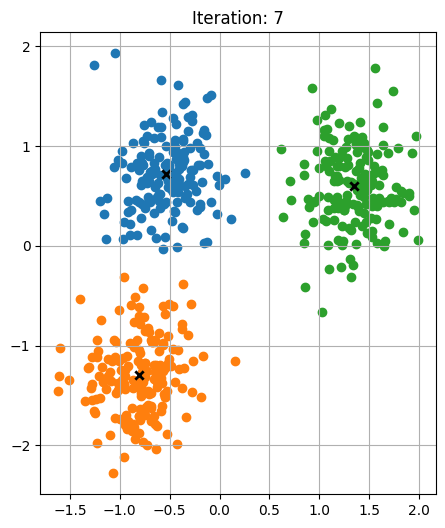

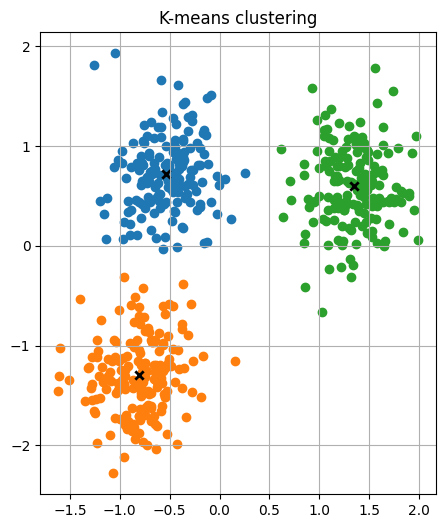

In [8]:
k_means = KMeans(K=3, max_iters=10, plot_steps=True)
y_pred = k_means.predict(X_std)

k_means.plot(title="K-means clustering")

### Summary

In this notebook we implemented K-Means clustering from scratch. The key takeaways are:

1. **K-Means is iterative**: It alternates between assigning points to the nearest centroid and recomputing centroids as the mean of each cluster.
2. **Convergence**: The algorithm stops when centroids no longer move. In practice, this typically happens within a small number of iterations.
3. **Feature scaling matters**: Since K-Means relies on Euclidean distance, features must be on comparable scales. StandardScaler achieves this.
4. **Initialization is random**: Different random initializations can lead to different final clusters. Techniques like K-Means++ (not shown here) improve initialization by choosing smarter starting centroids.